# Operational Oceanography Tutorial: Downloading Forecast Data from Copernicus Marine Service

**SAMOS Operational Oceanography — Practical Tutorial Monday 7. September**

In this tutorial you will:

1. Select a coastal region of South Africa to study.
2. Connect to the Copernicus Marine Service (CMEMS) and download **forecast** ocean data (temperature, salinity, and currents) for that region.
4. Load, inspect, and visualise the forecast data.
5. Complete some exercises to learn how to get addiotional datasets and plot derived datasets.

> **Data source:** Copernicus Marine Service (CMEMS), Global Ocean Physics Analysis and Forecast product (`GLOBAL_ANALYSISFORECAST_PHY_001_024`).

## 1. Setup

We will use the official `copernicusmarine` Python toolbox to search for and download data, together with `xarray` for working with the downloaded NetCDF files, and `matplotlib` and `cartopy` for mapping.

Run the cell below once to install everything you need (you can comment it out afterwards).


In [1]:
# Run once per environment (e.g. once per Colab session, or once in your local conda/venv)
%pip install -q copernicusmarine xarray matplotlib cartopy netCDF4


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from datetime import datetime, timedelta, timezone

import copernicusmarine
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Fatal Python error: config_get_locale_encoding: failed to get the locale encoding: nl_langinfo(CODESET) failed
Python runtime state: preinitialized



## 2. Log in to Copernicus Marine Service

You need a free Copernicus Marine account to download data, I think you all seigned up for it last week, if not sign up here
[data.marine.copernicus.eu](https://data.marine.copernicus.eu).

Running the cell below will prompt you for your username and password the first time. Your credentials are then cached locally, so you won't need to log in again on this machine.


In [3]:
copernicusmarine.login()


INFO - 2026-09-01T08:45:59Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  asamuelsen


Copernicus Marine password:

  ········


INFO - 2026-09-01T08:47:15Z - Credentials file stored in /Users/annettes/.copernicusmarine/.copernicusmarine-credentials.


True

## 3. Select your region

Choose one of the preset regions around South Africa from the numbered menu below. Each region is defined by a bounding box (minimum/maximum longitude and latitude). After you pick one, its outline is drawn on a map so you can check it before downloading any data.

| Region | Why it's interesting |
|---|---|
| **Agulhas Bank (South Coast)** | Wide continental shelf south of Africa; strong shelf-edge frontal dynamics |
| **Benguela Upwelling (West Coast)** | Eastern boundary upwelling system; cold, nutrient-rich water |
| **Agulhas Current Core (KZN to Port Elizabeth)** | Core of the fast, warm western boundary current |
| **Cape Town Coastal Waters** | Local coastal domain around Cape Town, influenced by both current systems |
| **Full South African EEZ (overview)** | Wide view of the whole South African coastline |

Feel free to add your own region to the `regions` dictionary if you want to study a different area.

Run the cell below, then type the **number** of the region you want at the prompt and press Enter.


Choose a region:

  1. Agulhas Bank (South Coast)
  2. Benguela Upwelling (West Coast)
  3. Agulhas Current Core (KZN to Port Elizabeth)
  4. Cape Town Coastal Waters
  5. Full South African EEZ (overview)



Enter a number (1-5):  1


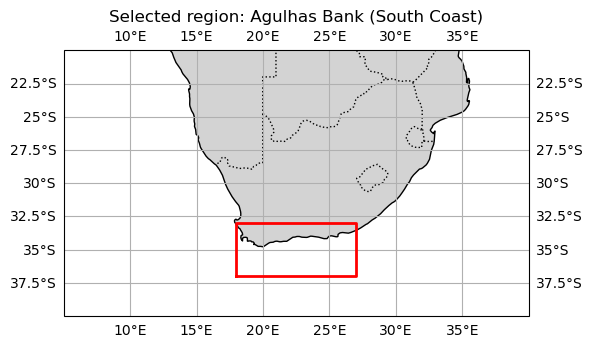

Bounding box -> lon: [18.0, 27.0], lat: [-37.0, -33.0]


In [21]:
regions = {
    "Agulhas Bank (South Coast)": {"lon_min": 18.0, "lon_max": 27.0, "lat_min": -37.0, "lat_max": -33.0},
    "Benguela Upwelling (West Coast)": {"lon_min": 14.0, "lon_max": 19.0, "lat_min": -34.0, "lat_max": -28.0},
    "Agulhas Current Core (KZN to Port Elizabeth)": {"lon_min": 29.0, "lon_max": 35.0, "lat_min": -32.0, "lat_max": -27.0},
    "Cape Town Coastal Waters": {"lon_min": 17.5, "lon_max": 19.5, "lat_min": -35.0, "lat_max": -33.5},
    "Full South African EEZ (overview)": {"lon_min": 10.0, "lon_max": 37.0, "lat_min": -37.0, "lat_max": -25.0},
}


def preview_region(region_name):
    bbox = regions[region_name]

    fig = plt.figure(figsize=(6, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([5, 40, -40, -20], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.gridlines(draw_labels=True)

    ax.plot(
        [bbox["lon_min"], bbox["lon_max"], bbox["lon_max"], bbox["lon_min"], bbox["lon_min"]],
        [bbox["lat_min"], bbox["lat_min"], bbox["lat_max"], bbox["lat_max"], bbox["lat_min"]],
        color="red", linewidth=2, transform=ccrs.PlateCarree(),
    )
    ax.set_title(f"Selected region: {region_name}")
    plt.show()

    print(
        f"Bounding box -> lon: [{bbox['lon_min']}, {bbox['lon_max']}], "
        f"lat: [{bbox['lat_min']}, {bbox['lat_max']}]"
    )


region_names = list(regions.keys())
print("Choose a region:\n")
for i, name in enumerate(region_names, start=1):
    print(f"  {i}. {name}")

choice = input(f"\nEnter a number (1-{len(region_names)}): ").strip()
selected_name = region_names[int(choice) - 1]

REGION_SELECTED = dict(regions[selected_name])
REGION_SELECTED["name"] = selected_name

preview_region(selected_name)


> **Tip:** To change region later, just re-run the cell above and enter a different number — then re-run the download and plotting cells below.


## 4. Download forecast data from Copernicus Marine

We will download four core variables for this tutorial:

- **`thetao`** — sea water potential temperature (°C)
- **`so`** — sea water salinity (PSU)
- **`uo`** — eastward sea water velocity (m/s)
- **`vo`** — northward sea water velocity (m/s)

from the **Global Ocean Physics Analysis and Forecast** product (`GLOBAL_ANALYSISFORECAST_PHY_001_024`), daily-mean resolution. This product is updated daily and provides forecasts several days into the future — `uo`/`vo` are especially relevant here since they let us look directly at the Agulhas Current and other coastal currents.

This product is organised as **one dataset per variable (or variable group)**, so each is downloaded from its own dataset ID:

- `cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m` → `thetao`
- `cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m` → `so`
- `cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m` → `uo`, `vo` (bundled together)

To keep the download small and fast (useful on slower connections), we:
- request only the **surface layer** (`minimum_depth=0`, `maximum_depth=1`),
- request a **5-day forecast window** starting today,
- clip to the **bounding box** you selected above.

> Copernicus Marine occasionally restructures its catalogue and dataset IDs can change. If a dataset ID below stops working, run `copernicusmarine.describe(contains=["GLOBAL_ANALYSISFORECAST_PHY_001_024"])` to list the current dataset IDs and the variables each one contains, or check the "Data access" tab for this product at [data.marine.copernicus.eu](https://data.marine.copernicus.eu).


In [22]:
assert REGION_SELECTED, "Please select a region first (Section 3)."

# dataset_id -> variables provided by that dataset
DATASETS = {
    "cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m": ["thetao"],
    "cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m": ["so"],
    "cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m": ["uo", "vo"],
}

today = datetime.now(timezone.utc).date()
start_datetime = today.isoformat()
end_datetime = (today + timedelta(days=5)).isoformat()

output_dir = "cmems_data"
os.makedirs(output_dir, exist_ok=True)

region_tag = REGION_SELECTED["name"].replace(" ", "_").replace("(", "").replace(")", "")

print(f"Region:  {REGION_SELECTED['name']}")
print(f"Bbox:    lon [{REGION_SELECTED['lon_min']}, {REGION_SELECTED['lon_max']}], "
      f"lat [{REGION_SELECTED['lat_min']}, {REGION_SELECTED['lat_max']}]")
print(f"Forecast window: {start_datetime} to {end_datetime}")


Region:  Agulhas Bank (South Coast)
Bbox:    lon [18.0, 27.0], lat [-37.0, -33.0]
Forecast window: 2026-09-01 to 2026-09-06


In [23]:
downloaded_files = []

for dataset_id, variables in DATASETS.items():
    variable_tag = "_".join(variables)
    output_filename = f"{region_tag}_{variable_tag}_forecast.nc"
    print(f"Downloading {variables} from {dataset_id} ...")

    copernicusmarine.subset(
        dataset_id=dataset_id,
        variables=variables,
        minimum_longitude=REGION_SELECTED["lon_min"],
        maximum_longitude=REGION_SELECTED["lon_max"],
        minimum_latitude=REGION_SELECTED["lat_min"],
        maximum_latitude=REGION_SELECTED["lat_max"],
        start_datetime=start_datetime,
        end_datetime=end_datetime,
        minimum_depth=0,
        maximum_depth=1,
        output_directory=output_dir,
        output_filename=output_filename,
    )
    downloaded_files.append(os.path.join(output_dir, output_filename))

downloaded_files


INFO - 2026-09-01T08:58:25Z - Selected dataset version: "202406"
INFO - 2026-09-01T08:58:25Z - Selected dataset part: "default"
WARNING - 2026-09-01T08:58:25Z - Some of your subset selection [0, 1] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-01T08:58:26Z - Starting download. Please wait...
INFO - 2026-09-01T08:58:26Z - Successfully downloaded to cmems_data/Agulhas_Bank_South_Coast_thetao_forecast_(1).nc


INFO - 2026-09-01T08:58:27Z - Selected dataset version: "202406"
INFO - 2026-09-01T08:58:27Z - Selected dataset part: "default"
WARNING - 2026-09-01T08:58:27Z - Some of your subset selection [0, 1] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-01T08:58:28Z - Starting download. Please wait...
INFO - 2026-09-01T08:58:29Z - Successfully downloaded to cmems_data/Agulhas_Bank_South_Coast_so_forecast_(1).nc


INFO - 2026-09-01T08:58:30Z - Selected dataset version: "202406"
INFO - 2026-09-01T08:58:30Z - Selected dataset part: "default"
WARNING - 2026-09-01T08:58:30Z - Some of your subset selection [0, 1] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
INFO - 2026-09-01T08:58:31Z - Starting download. Please wait...
INFO - 2026-09-01T08:58:33Z - Successfully downloaded to cmems_data/Agulhas_Bank_South_Coast_uo_vo_forecast_(1).nc


['cmems_data/Agulhas_Bank_South_Coast_thetao_forecast.nc',
 'cmems_data/Agulhas_Bank_South_Coast_so_forecast.nc',
 'cmems_data/Agulhas_Bank_South_Coast_uo_vo_forecast.nc']

## 5. Load and explore the forecast data

Each variable was downloaded into its own NetCDF file. We open both with `xarray` and merge them into a single dataset, then take a look at its structure: dimensions, coordinates, and variables.


In [24]:
# engine="netcdf4" avoids needing the optional h5py/h5netcdf packages
ds = xr.merge([xr.open_dataset(path, engine="netcdf4") for path in downloaded_files])
ds


<xarray.Dataset>
Dimensions:    (depth: 1, latitude: 49, longitude: 109, time: 6)
Coordinates:
  * depth      (depth) float32 0.494
  * latitude   (latitude) float32 -37.0 -36.92 -36.83 ... -33.17 -33.08 -33.0
  * longitude  (longitude) float32 18.0 18.08 18.17 18.25 ... 26.83 26.92 27.0
  * time       (time) datetime64[ns] 2026-08-30 2026-08-31 ... 2026-09-04
Data variables:
    thetao     (time, depth, latitude, longitude) float32 ...
    so         (time, depth, latitude, longitude) float32 ...
    uo         (time, depth, latitude, longitude) float32 ...
    vo         (time, depth, latitude, longitude) float32 ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     daily mean fields from Global Ocean Physics An...
    copernicusmarine_version:  2.3.0

Take a moment to check:

- What are the dimensions of `thetao` and `so` (time, depth, latitude, longitude)?
- How many forecast days did you download?
- What are the units of each variable (check the variable's `attrs`)?


In [25]:
for variable in ["thetao", "so", "uo", "vo"]:
    print(variable, "->", ds[variable].attrs)


thetao -> {'cell_methods': 'area: mean', 'long_name': 'Temperature', 'standard_name': 'sea_water_potential_temperature', 'unit_long': 'Degrees Celsius', 'units': 'degrees_C', 'valid_max': 40.0, 'valid_min': -10.0}
so -> {'cell_methods': 'area: mean', 'long_name': 'Salinity', 'standard_name': 'sea_water_salinity', 'unit_long': 'Practical Salinity Unit', 'units': '1e-3', 'valid_max': 50.0, 'valid_min': 0.0}
uo -> {'cell_methods': 'area: mean', 'long_name': 'Eastward velocity', 'standard_name': 'eastward_sea_water_velocity', 'unit_long': 'Meters per second', 'units': 'm s-1', 'valid_max': 5.0, 'valid_min': -5.0}
vo -> {'cell_methods': 'area: mean', 'long_name': 'Northward velocity', 'standard_name': 'northward_sea_water_velocity', 'unit_long': 'Meters per second', 'units': 'm s-1', 'valid_max': 5.0, 'valid_min': -5.0}


## 6. Visualise the forecast

Let's map sea surface temperature, salinity, and current speed (with current direction as arrows) for the **first forecast day** (today) over your selected region.


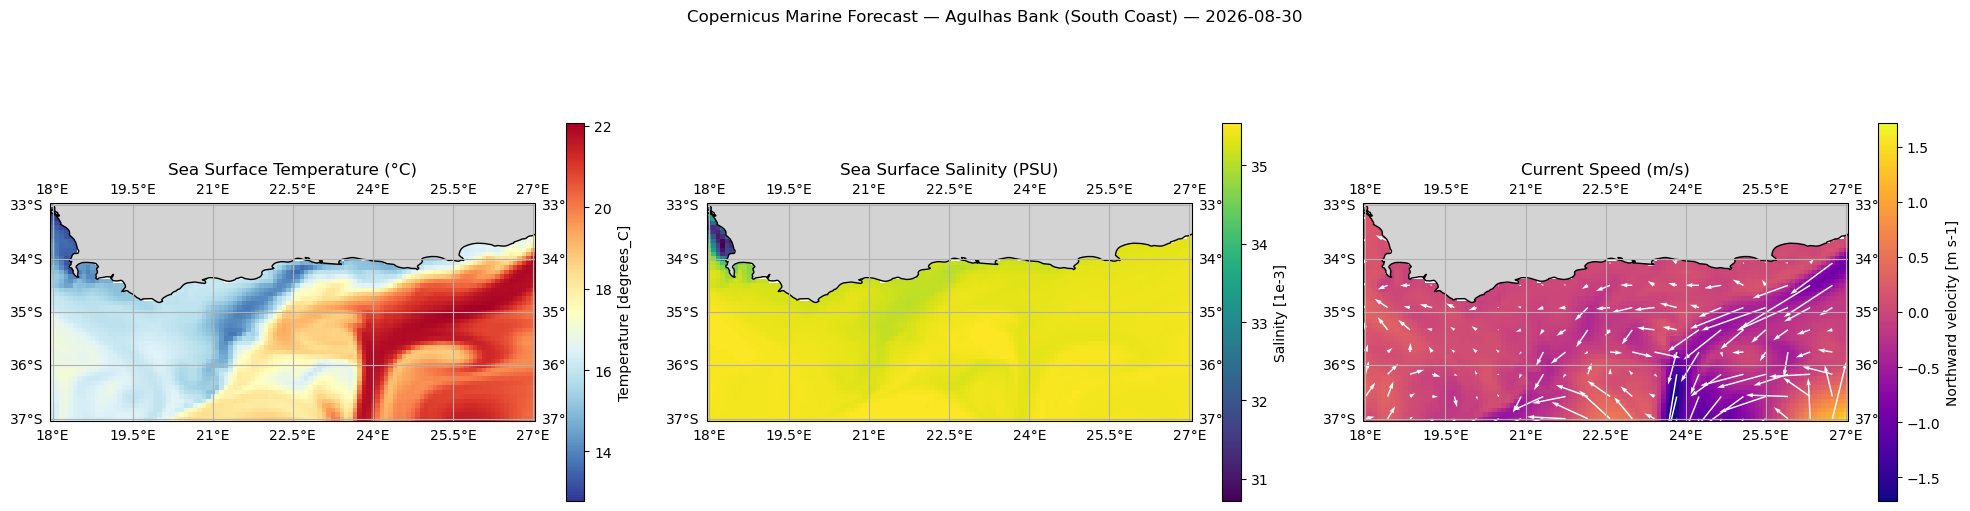

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={"projection": ccrs.PlateCarree()})

sst = ds["thetao"].isel(time=0, depth=0)
sss = ds["so"].isel(time=0, depth=0)
u = ds["uo"].isel(time=0, depth=0)
v = ds["vo"].isel(time=0, depth=0)
speed = np.sqrt(u ** 2 + v ** 2)
speed.attrs["units"] = "m/s"


panels = [
    (sst, "Sea Surface Temperature (°C)", "RdYlBu_r"),
    (sss, "Sea Surface Salinity (PSU)", "viridis"),
    (v, "Current Speed (m/s)", "plasma"),
]

for ax, (data, title, cmap) in zip(axes, panels):
    data.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap=cmap,
        cbar_kwargs={"shrink": 0.7},
    )
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.gridlines(draw_labels=True)
    ax.set_title(title)

# Overlay current direction arrows on the current-speed panel (subsampled so it stays readable)
skip = max(len(u.longitude) // 20, 1)
axes[2].quiver(
    u.longitude.values[::skip], u.latitude.values[::skip],
    u.values[::skip, ::skip], v.values[::skip, ::skip],
    transform=ccrs.PlateCarree(), color="white", scale=10, width=0.003,
)

plt.suptitle(f"Copernicus Marine Forecast — {REGION_SELECTED['name']} — {str(ds.time.values[0])[:10]}")
plt.tight_layout()
plt.show()


## 7. Exercises

Try the following on your own, reusing the code above:

1. **Compare regions.** Go back to Section 3, select a different region (e.g. switch from the Agulhas Bank to the Benguela Upwelling), re-run the download and plotting cells, and compare the temperature and salinity patterns. What differences do you notice, and why?
2. **Change the region.** Modify the extet of one of the 5 regions or add your own region as an option in the list above.
3. **Look further ahead.** Instead of `time=0`, plot the last day of the forecast (`time=-1`). How much does the temperature and salinity change over the 5-day forecast window?
4. **Look at a time series (stretch goal).** Pick a single location inside your region (a longitude/latitude pair), extract the forecast temperature at that point across all 5 days using `.sel(longitude=..., latitude=..., method="nearest")`, and plot it as a simple time series with `matplotlib`.
5. **Discussion.** Some applications of forecast were presented in the lecture today.  In groups of 3 dicsuss potential applications of these forecasts.  
6. **Add a variable of your own.** The notebook currently downloads temperature, salinity, and currents. Pick another variable from the same product — for example `zos` (sea surface height, dataset `cmems_mod_glo_phy-ssh_anfc_0.083deg_P1D-m`) or `mlotst` (mixed layer depth, dataset `cmems_mod_glo_phy-mld_anfc_0.083deg_P1D-m`) — and extend Section 4 and Section 6 to download and plot it too. To find the exact dataset ID and confirm which variables it contains, run:
   ```python
   copernicusmarine.describe(contains=["GLOBAL_ANALYSISFORECAST_PHY_001_024"])
   ```
   Use the existing `thetao`/`so`/`uo`/`vo` code as your template: add an entry to the `DATASETS` dictionary, then add a new panel to the plotting figure.
7. **Compare 'time=0' to satelite observations** Based on what you learned last week, can you look for a suitabel dataset to compare the model fields to.

## Useful references

- Copernicus Marine Service catalogue: <https://data.marine.copernicus.eu>
- `copernicusmarine` toolbox documentation: <https://help.marine.copernicus.eu/en/collections/9080063-copernicus-marine-toolbox>
- Product used in this tutorial: *Global Ocean Physics Analysis and Forecast* (`GLOBAL_ANALYSISFORECAST_PHY_001_024`)
